In [1]:
import os
import sys
import gzip
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import pandas as pd
import re

from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from skimage import restoration

import euclid_psf as ep

sys.path.insert(0, '/home/eaev/mer_psf/')
from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf

In [2]:
warnings.simplefilter('ignore', FITSFixedWarning)

In [3]:
# Links to shared folders
dbx_url = 'https://www.dropbox.com/scl/fo/37ooho4m924wb3d2m1gt8/ABJjd8gNUl0h_rmUP41S3cI?rlkey=nqy0t7p9sgxa3a853bf1ris9l&st=clxv8yui&dl=0'
# jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
# nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

In [4]:
def pixel_scale(wcs):
    # Convert one arcsecond to pixels
    start = wcs.pixel_to_world(0,0)
    sep = 1*u.arcsecond
    end = start.directional_offset_by(0*u.arcsecond, sep)
    x0, x1 = wcs.world_to_pixel(start), wcs.world_to_pixel(end)
    x0, x1 = np.array(x0).flatten(), np.array(x1).flatten()
    hyp = x0+x1
    return 1/np.sqrt(np.dot(hyp, hyp)) # arcsec / pixel

def get_shared_folder_metadata(url, dbx, path=""):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path=f'{path}', shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def get_fits_file(url, file_name, dbx, hdu_idx=0):
    tries=5
    while tries >= 0:
        tries -= 1
        try:
            meta, res = dbx.sharing_get_shared_link_file(url, path=file_name)
            break
        except Exception as e:
            print(f"Connection error: {e}")
            time.sleep(10)
            continue

    try: res
    except: raise RuntimeError(f"Could not access file {file_name} at URL {url}.")

    # Unzip file, if necessary
    if '.gz' in file_name:
        with gzip.GzipFile(fileobj=BytesIO(res.content), mode='rb') as f_in:
            decompressed_data = f_in.read()
    else: decompressed_data = res.content

    fits_file = BytesIO(decompressed_data)
    hdul = fits.open(fits_file)

    # Access image data
    image_data = hdul[hdu_idx].data
    image_header = hdul[hdu_idx].header
    hdul.close()
    return image_header, image_data

def cut_catalog(cat_file, cuts=None):
    # Open cat file
    with fits.open(cat_file) as hdul:
        cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension
    
    # Do cuts on catalog data
    if cuts is None:
        cuts = (cat_data.lp_type==0) & \
                (cat_data.ACS_F814W_MAG < 25) & \
                (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                (cat_data.FLUX_RADIUS < 104) # TODO: make this a function with J&H bands?
    
    cat_clipped = cat_data[cuts]
    
    my_cat = pd.DataFrame({'id_classic': cat_clipped['ID'].astype(int),
                           'ra': cat_clipped['ALPHA_J2000'].astype(float),
                           'dec': cat_clipped['DELTA_J2000'].astype(float),
                           'jwst_image': "",
                           'nisp_image': "",
                          })
    
    return my_cat

def cut_catalog2(cat_file, cuts=None):

    cat_data = Table.read(cat_file).to_pandas()
    
    cat_data['ACS_F814W_MAG'] = 23.9-2.5*np.log10(cat_data.ACS_F814W_FLUX)
    cat_clipped = cat_data[
            (cat_data.z_best > 0.01) & (cat_data.z_best < 3.0)
            & (cat_data.ACS_F814W_MAG < 25)
            & (cat_data.FLUX_RADIUS_2_F814W < 50) & (cat_data.FLUX_RADIUS_2_F814W > 3) # Can be flexible with this (remove or make much larger)
            & (cat_data.CLASS_STAR < 0.1)
    ]

    my_cat = pd.DataFrame({
        'id': cat_clipped['ID'],
        'ra': cat_clipped['RA_1'],
        'dec': cat_clipped['DEC_1'],
        'jwst_image': '',
        'nisp_image': '',
    })

    my_cat = my_cat.dropna().reset_index(drop=True)
    return my_cat

def psf_filename(filename):
    tile_id = re.search("TILE([0-9]{9})", filename)[1]
    cat_file = glob.glob(f"../data/*/EUC_MER_CATALOG-PSF-NIR-Y_TILE{tile_id}*.fits")
    if len(cat_file)==0: raise ValueError(f"No matches for TILE ID {tile_id}")
    elif len(cat_file)>1: raise ValueError(f"Too many files match TILE ID {tile_id}")

    return cat_file[0]

def match_catalog(file_name, gal_coords, hdu_idx=0, url=None, dbx=None):
    if url is None or dbx is None: # get images locally
        if not os.path.exists(file_name):
            raise ValueError(f"File name '{file_name}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")
        with fits.open(file_name) as hdul:
            image_header = hdul[hdu_idx].header
            image_data = hdul[hdu_idx].data
    else: # Get FITS file from dropbox
        image_header, image_data = get_fits_file(url, file_name, dbx=dbx, 
                                                 hdu_idx=hdu_idx)
    
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

def rotate_jwst(clip, angle=-20, size=69, pad=20):
    # There are different types of interpolation possible for this one, talk about it with Shooby
    wcs = clip.wcs
    new_image = ndimage.rotate(clip.data, angle, reshape=False, order=3, cval=-20)
    new_clip = Cutout2D(new_image, clip.center_cutout, size)
    # new_clip.wcs = wcs
    return new_clip # no WCS info after this

def mirror_cutout_along_y(cutout):
    """
    Mirror a Cutout2D object along the y-axis (flip horizontally),
    updating both the data and WCS information.
    
    Parameters:
    -----------
    cutout : Cutout2D
        The input cutout with valid WCS
        
    Returns:
    --------
    Cutout2D
        A new Cutout2D object with mirrored data and corrected WCS
    """
    # Create a deep copy to avoid modifying the original
    new_cutout = deepcopy(cutout)
    
    # Flip the image data horizontally
    new_cutout.data = np.fliplr(cutout.data)
    
    # Get the original WCS
    old_wcs = cutout.wcs
    
    # Create a new WCS object
    new_wcs = WCS(naxis=old_wcs.naxis)
    
    # Copy over the basic WCS parameters
    new_wcs.wcs.crval = old_wcs.wcs.crval.copy()
    new_wcs.wcs.crpix = old_wcs.wcs.crpix.copy()
    new_wcs.wcs.cdelt = old_wcs.wcs.cdelt.copy()
    
    # Get the transformation matrix (either CD or PC)
    if hasattr(old_wcs.wcs, 'cd'):
        old_matrix = old_wcs.wcs.cd.copy()
        # Flip the sign of the first column (RA components)
        new_matrix = old_matrix.copy()
        new_matrix[:, 0] = -old_matrix[:, 0]
        new_wcs.wcs.cd = new_matrix
    else:
        old_matrix = old_wcs.wcs.pc.copy()
        # Flip the sign of the first column (RA components)
        new_matrix = old_matrix.copy()
        new_matrix[:, 0] = -old_matrix[:, 0]
        new_wcs.wcs.pc = new_matrix
        # Also need to flip the sign of the RA scale
        new_wcs.wcs.cdelt[0] = -old_wcs.wcs.cdelt[0]
    
    # Update the reference pixel x-coordinate
    # For a horizontal flip, the new reference pixel is at (width - x)
    width = cutout.data.shape[1]
    new_wcs.wcs.crpix[0] = width + 1 - old_wcs.wcs.crpix[0]
    
    # Copy over any additional WCS attributes
    for attr in ['ctype', 'cunit', 'lonpole', 'latpole', 'radesys', 'equinox']:
        if hasattr(old_wcs.wcs, attr):
            setattr(new_wcs.wcs, attr, getattr(old_wcs.wcs, attr))

    new_cutout.wcs = new_wcs
    
    return new_cutout

def clip_images(catalog, url=None, dbx=None, size_jwst=69, size_nisp=41, pad=20, 
                rot_jwst=-20.0, limit=None, jwst_hdu=0, nisp_hdu=0, deconvolve=True,
                mirror_euclid=False,
               ):
    ### The catalog must have matched ra, dec, jwst_image, and nisp_image columns
    image_pairs = catalog.groupby(['jwst_image', 'nisp_image'])

    clips = []
    count = 0
    for match, cat in image_pairs:
        jwst_file, nisp_file = match

        # Open JWST and Euclid images
        if dbx is None or url is None: # Open from file
            
            # Check files exist
            if not os.path.exists(jwst_file):
                raise ValueError(f"File name '{jwst_file}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")
            if not os.path.exists(nisp_file):
                raise ValueError(f"File name '{nisp_file}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")

            # Open JWST and NISP files from disk
            with fits.open(jwst_file) as hdul:
                jwst_header = hdul[jwst_hdu].header
                jwst_data = hdul[jwst_hdu].data
            with fits.open(nisp_file) as hdul:
                nisp_header = hdul[nisp_hdu].header
                nisp_data = hdul[nisp_hdu].data
                
        else: # Open from dropbox
            print('Fetching files from dropbox...')
            jwst_header, jwst_data = get_fits_file(url, jwst_file, dbx=dbx, hdu_idx=jwst_hdu)
            nisp_header, nisp_data = get_fits_file(url, nisp_file, dbx=dbx, hdu_idx=nisp_hdu)

        if deconvolve:
            psf_file = psf_filename(nisp_file)
            psf = mpsf.from_file(psf_file)
        
        wcs_jwst, wcs_nisp = WCS(jwst_header), WCS(nisp_header)
        
        # Get the coordinates of matched galaxies
        gal_coords = SkyCoord(cat.ra, cat.dec, unit='deg')
        
        for i in range(len(cat)):
            gal = cat.iloc[i]
            # Get JWST clip (larger than final size)
            clip_jwst = Cutout2D(jwst_data, gal_coords[i], size=size_jwst+pad, wcs=wcs_jwst, mode='trim')
            if sum(clip_jwst.data.shape)!=(size_jwst+pad)*2: continue
            if np.sum((clip_jwst.data==0.0).astype(int))/((size_jwst+pad)**2) > 0.25: continue
            
            # Get NISP clip
            clip_nisp = Cutout2D(nisp_data, gal_coords[i], size=size_nisp, wcs=wcs_nisp, mode='trim')
            if sum(clip_nisp.data.shape)!=(size_nisp)*2: continue
            if np.sum((clip_nisp.data==0.0).astype(int))/((size_nisp)**2) > 0.25: continue
            # clip_nisp.data = ABmag_nisp(clip_nisp, nisp_header['MAGZERO'])

            # if deconvolve:
            #     # Get PSF clip
            #     psf = epsf.evaluate(gal_coords[i])
            #     if psf.shape[0]!=33:
            #         raise ValueError(f"PSF size not as expected in file {psf_file}")
    
            #     # Deconvolve Euclid with PSF
            #     deconv, _ = restoration.unsupervised_wiener(clip_nisp.data, psf, clip=False)
            #     clip_nisp.data = deconv
            if deconvolve:
                psf_clip = psf.get_closest_stamp_at_radec([gal_coords[i].ra.degree, 
                                                            gal_coords[i].dec.degree])
                psf_clip.normalize()
                psf_data = psf_clip.get_data()
            
            # Rotate JWST image 20 degrees counter-clockwise and crop
            # This loses the WCS
            if rot_jwst != 0:
                clip_jwst = rotate_jwst(clip_jwst, size=size_jwst, angle=rot_jwst)
                # clip_jwst.wcs = rotate_wcs(clip_jwst, angle=rot_jwst)
            # clip_jwst.data = ABmag_jwst(clip_jwst, jwst_header['PIXAR_SR'])
            
            clips.append((gal_coords[i], clip_jwst, clip_nisp))
            count += 1
            if limit is not None and count >= limit: break
        if limit is not None and count >= limit: break

    return clips

In [5]:
meta = {
    'cosmos': {
        'NISP-Y_MER': {
            'cut_func': cut_catalog,
            'jwst_hdu': 0,
            'nisp_hdu': 0,
            'cat_path': '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits', # COSMOS classic
            'size_jwst': 69, # Change to 41 and 69 px
            'size_nisp': 41,
            'pad_jwst': 20,
            'rot_jwst': -20,
            'psf_hdu': 1,
            'matched_cat': '../catalog/matched_cat_cosmos_1.csv',
            'matched_jwst': '../data/jwst_cosmos_69px_F115W.npy',
            'matched_nisp': '../data/euclid_MER_cosmos_41px_Y.npy',
            # 'matched_nisp_psf': '../data/nisp_cosmos_psf.npy',
        },
        'NISP-Y': {
            'cut_func': cut_catalog,
            'jwst_hdu': 0,
            'nisp_hdu': 1,
            'cat_path': '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits', # COSMOS classic
            'size_jwst': 205,
            'size_nisp': 41,
            'mirror_euclid': True,
            'pad_jwst': 20,
            'rot_jwst': -3.945,
            'matched_cat': '../catalog/matched_cat_cosmos_2.csv',
            'matched_jwst': '../data/jwst_cosmos_205px_F115W.npy',
            'matched_nisp': '../data/euclid_NIR_cosmos_41px_Y.npy',
        },
    },
    'HUDF': {
        'NISP-Y_MER': {
            'cut_func': cut_catalog2,
            'jwst_hdu': 1,
            'nisp_hdu': 0,
            'cat_path': '../catalog/gds.fits', # CANDELS catalog
            'size_jwst': 135, # Change to an odd # of pixels
            'size_nisp': 41,
            'pad_jwst': 0,
            'rot_jwst': 0,
            'psf_hdu': 1,
            'matched_cat': '../catalog/matched_cat_hudf_1.csv',
            'matched_jwst': '../data/jwst_hudf_135px_F115W.npy',
            'matched_nisp': '../data/euclid_MER_hudf_41px_Y.npy',
            # 'matched_nisp_psf': '../data/nisp_hudf_psf.npy',
        },
        'NISP-Y': {
            'cut_func': cut_catalog2,
            'jwst_hdu': 1,
            'nisp_hdu': 1,
            'cat_path': '../catalog/gds.fits', # CANDELS catalog
            'size_jwst': 205,
            'size_nisp': 41,
            'pad_jwst': 0,
            'rot_jwst': 0,
            'matched_cat': '../catalog/matched_cat_hudf_2.csv',
            'matched_jwst': '../data/jwst_hudf_205px_F115W.npy',
            'matched_nisp': '../data/euclid_NIR_hudf_41px_Y.npy',
        },
    },
}

In [6]:
def process_all(field='cosmos', euclid_type='NISP-Y_MER', save_cat=False, save_clips=False, redo_cat=False,
                redo_clips=False, secret="../../secrets/dropbox_token", meta=meta,
                deconvolve=False):
    params = meta[field][euclid_type]

    # Try to load clip files from disk
    if (os.path.exists(params['matched_jwst']) and os.path.exists(params['matched_nisp']) 
            and not redo_clips and not redo_cat):
        print("Matched clip files exist; not re-running")
        jwst_cutouts = np.load(params['matched_jwst'])
        nisp_cutouts = np.load(params['matched_nisp'])
        return jwst_cutouts, nisp_cutouts
    
    # Instantiate dropbox token
    with open(secret) as token_file:
        token = token_file.read()
        dbx = dropbox.Dropbox(token.strip(), timeout=None)

    # Get JWST files for specific field
    jwst_path = f'/JWST/{field}/'
    jwst_files = get_shared_folder_metadata(dbx_url, dbx=dbx, path=jwst_path)
    jwst_files = [jwst_path+file.name for file in jwst_files]

    # Get NISP files for specific field
    nisp_path = f'/{euclid_type}/{field}/'
    nisp_files = get_shared_folder_metadata(dbx_url, dbx=dbx, path=nisp_path)
    nisp_files = [nisp_path+file.name for file in nisp_files if 'IMAGE' in file.name]

    # Try to load cat file from disk
    if os.path.exists(params['matched_cat']) and not redo_cat:
        print(f"Matched catalog file {params['matched_cat']} exists; not re-running.")
        my_cat = pd.read_csv(params['matched_cat'])
    else:
        # Apply cuts to the catalog
        my_cat = params['cut_func'](params['cat_path'])
        gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')
    
        # Match JWST files
        for file in jwst_files:
            found_idxs = match_catalog(file, gal_coords, url=dbx_url, dbx=dbx, 
                                       hdu_idx=params['jwst_hdu'])
            my_cat.loc[found_idxs, 'jwst_image'] = str(file)
    
        # Match NISP files
        for file in nisp_files:
            found_idxs = match_catalog(file, gal_coords, url=dbx_url, dbx=dbx,
                                       hdu_idx=params['nisp_hdu'])
            my_cat.loc[found_idxs, 'nisp_image'] = str(file)
    
        my_cat = my_cat[my_cat.nisp_image!='']
        my_cat = my_cat[my_cat.jwst_image!='']
    
        if save_cat:
            my_cat.to_csv(params['matched_cat'], index=False)
    
    # Clip images
    clips = clip_images(my_cat, url=dbx_url, dbx=dbx, jwst_hdu=params['jwst_hdu'], 
                        size_jwst=params['size_jwst'], rot_jwst=params['rot_jwst'], 
                        size_nisp=params['size_nisp'], pad=params['pad_jwst'],
                        nisp_hdu=params['nisp_hdu'], deconvolve=deconvolve)
    
    # Arrange data
    jwst_cutouts = np.array([clip[1].data for clip in clips])

    if euclid_type=='NISP-Y':
        for clip in clips:
            clip[2].data = np.fliplr(clip[2].data)
    nisp_cutouts = np.array([clip[2].data for clip in clips])
    
    if save_clips:
        np.save(params['matched_jwst'], jwst_cutouts, allow_pickle=False)
        np.save(params['matched_nisp'], nisp_cutouts, allow_pickle=False)
    
    return jwst_cutouts, nisp_cutouts

from astropy.wcs.utils import skycoord_to_pixel, pixel_to_skycoord

def get_relative_rotation_vector(cutout1, cutout2):
    """
    Calculate relative rotation by transforming a vector between the two frames.
    """
    wcs1 = cutout1.wcs
    wcs2 = cutout2.wcs
    
    # Define two points in the first cutout
    center = np.array([cutout1.shape[1]/2, cutout1.shape[0]/2])
    point2 = center + np.array([0, 100])  # 100 pixels in y direction
    
    # Convert to sky coordinates
    center_sky = pixel_to_skycoord(center[0], center[1], wcs1)
    point2_sky = pixel_to_skycoord(point2[0], point2[1], wcs1)
    
    # Convert back to pixel coordinates in the second cutout
    center_pix2 = skycoord_to_pixel(center_sky, wcs2)
    point2_pix2 = skycoord_to_pixel(point2_sky, wcs2)
    
    # Calculate the vector in both coordinate systems
    vec1 = np.array([0, 100])  # Original vector (0, 100)
    vec2 = np.array([point2_pix2[0] - center_pix2[0], 
                     point2_pix2[1] - center_pix2[1]])
    
    # Calculate the angle between the vectors
    angle1 = np.arctan2(vec1[1], vec1[0])
    angle2 = np.arctan2(vec2[1], vec2[0])
    
    # Return the relative rotation in degrees
    rel_angle = np.degrees(angle2 - angle1)
    
    # Normalize to range [-180, 180]
    if rel_angle > 180:
        rel_angle -= 360
    elif rel_angle < -180:
        rel_angle += 360
        
    return rel_angle

def plot_on_clip(base_clip, other_clip):
    base_size, other_size = base_clip.data.shape[0], other_clip.data.shape[0]
    corners = np.array([[0,0],[0,other_size],[other_size,other_size],[other_size,0],[0,0]])
    corners_sky = other_clip.wcs.pixel_to_world(corners[:,1], corners[:,0])
    corners_base = base_clip.wcs.world_to_pixel(corners_sky)

    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(base_clip.data, origin='lower')
    axes[0].plot(corners_base[0], corners_base[1], 'r--')
    axes[1].imshow(other_clip.data, origin='lower')
    plt.show()

    base_scale = pixel_scale(base_clip.wcs)
    other_scale = pixel_scale(other_clip.wcs)

    print(f"Base clip scale: {base_scale:.2f} \nOther clip scale: {other_scale:.2f}")
    print(f"Base clip should be {other_scale/base_scale:.4f}x larger than other clip")

from copy import deepcopy

import numpy as np
from astropy.wcs import WCS
from copy import deepcopy
from scipy.ndimage import rotate
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel

def rotate_cutout_with_wcs(cutout, angle_deg, reshape=True, order=1, fill_value=0):
    """
    Rotate a Cutout2D object by a specified angle in degrees,
    updating both the data and WCS information to maintain proper alignment.
    
    Parameters:
    -----------
    cutout : Cutout2D
        The input cutout with valid WCS
    angle_deg : float
        Rotation angle in degrees (positive is counterclockwise)
    reshape : bool, optional
        Whether to reshape the output to contain the entire rotated image
    order : int, optional
        Order of spline interpolation (0-5). Default is 1 (bilinear)
    fill_value : float, optional
        Value used to fill areas outside the input image
        
    Returns:
    --------
    tuple
        (rotated_data, rotated_wcs)
    """
    # Get the original WCS and data
    original_wcs = cutout.wcs
    original_data = cutout.data
    
    # Get the center of the original image in pixel coordinates
    old_center_pix = np.array([(original_data.shape[1] - 1) / 2, 
                              (original_data.shape[0] - 1) / 2])
    
    # Get the center in sky coordinates
    old_center_sky = pixel_to_skycoord(old_center_pix[0], old_center_pix[1], original_wcs)
    
    # Rotate the image data
    rotated_data = rotate(original_data, angle_deg, reshape=reshape, 
                          order=order, mode='constant', cval=fill_value)
    
    # Get the center of the rotated image
    if reshape:
        new_center_pix = np.array([(rotated_data.shape[1] - 1) / 2, 
                                  (rotated_data.shape[0] - 1) / 2])
    else:
        new_center_pix = old_center_pix
    
    # Create a new WCS object
    new_wcs = WCS(naxis=2)
    
    # Copy basic WCS parameters
    new_wcs.wcs.ctype = original_wcs.wcs.ctype
    if hasattr(original_wcs.wcs, 'cunit'):
        new_wcs.wcs.cunit = original_wcs.wcs.cunit
    new_wcs.wcs.crval = old_center_sky.spherical.lon.deg, old_center_sky.spherical.lat.deg
    
    # Set the reference pixel to the center of the rotated image
    new_wcs.wcs.crpix = new_center_pix + 1  # +1 because FITS is 1-indexed
    
    # Create a rotation matrix for the angle
    angle_rad = np.radians(angle_deg)
    rot_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    
    # Get the original transformation matrix
    if hasattr(original_wcs.wcs, 'cd'):
        # CD matrix case
        cd_matrix = original_wcs.wcs.cd
        # Apply rotation to the CD matrix
        new_cd = np.dot(rot_matrix, cd_matrix)
        new_wcs.wcs.cd = new_cd
    else:
        # PC matrix case
        pc_matrix = original_wcs.wcs.pc
        cdelt = original_wcs.wcs.cdelt
        
        # Apply rotation to the PC matrix
        new_pc = np.dot(rot_matrix, pc_matrix)
        new_wcs.wcs.pc = new_pc
        new_wcs.wcs.cdelt = cdelt
    
    # Copy other WCS attributes
    for attr in ['radesys', 'equinox', 'lonpole', 'latpole']:
        if hasattr(original_wcs.wcs, attr):
            setattr(new_wcs.wcs, attr, getattr(original_wcs.wcs, attr))
    
    return rotated_data, new_wcs

In [7]:
def rotate_cutout_with_wcs(cutout, angle_deg, reshape=True, order=1, fill_value=0):
    """
    Rotate a Cutout2D object by a specified angle in degrees,
    ensuring rotation happens around the center of the image.
    
    Parameters:
    -----------
    cutout : Cutout2D
        The input cutout with valid WCS
    angle_deg : float
        Rotation angle in degrees (positive is counterclockwise)
    reshape : bool, optional
        Whether to reshape the output to contain the entire rotated image
    order : int, optional
        Order of spline interpolation (0-5). Default is 1 (bilinear)
    fill_value : float, optional
        Value used to fill areas outside the input image
        
    Returns:
    --------
    tuple
        (rotated_data, rotated_wcs)
    """
    
    # Get the original data and WCS
    original_data = cutout.data
    original_wcs = cutout.wcs
    
    # Get dimensions of the original image
    ny, nx = original_data.shape
    
    # Rotate the image data (scipy.ndimage.rotate rotates around the center by default)
    rotated_data = ndimage.rotate(original_data, angle_deg, reshape=reshape, 
                         order=order, mode='constant', cval=fill_value)
    
    # Create a new WCS object
    new_wcs = deepcopy(original_wcs)
    
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    
    # Create rotation matrix
    rot_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    
    # Apply rotation to CD/PC matrix
    if hasattr(original_wcs.wcs, 'cd'):
        # CD matrix case
        cd = original_wcs.wcs.cd.copy()
        new_wcs.wcs.cd = np.dot(rot_matrix, cd)
    else:
        # PC matrix case
        pc = original_wcs.wcs.pc.copy()
        new_wcs.wcs.pc = np.dot(rot_matrix, pc)
    
    # Calculate the shift needed for rotation around center
    # The key insight: we need to adjust CRPIX to account for 
    # rotation around the center and not (0,0)
    
    # Center of the original image (0-indexed)
    x_center = (nx - 1) / 2
    y_center = (ny - 1) / 2
    
    # Vector from center to CRPIX (0-indexed)
    dx = original_wcs.wcs.crpix[0] - 1 - x_center
    dy = original_wcs.wcs.crpix[1] - 1 - y_center
    
    # Rotate this vector
    dx_rot, dy_rot = np.dot(rot_matrix, [dx, dy])
    
    # If reshape=True, get the center of the new image
    if reshape:
        ny_new, nx_new = rotated_data.shape
        x_center_new = (nx_new - 1) / 2
        y_center_new = (ny_new - 1) / 2
    else:
        x_center_new = x_center
        y_center_new = y_center
    
    # Calculate new CRPIX (1-indexed)
    new_wcs.wcs.crpix[0] = x_center_new + dx_rot + 1
    new_wcs.wcs.crpix[1] = y_center_new + dy_rot + 1
    
    return rotated_data, new_wcs

In [8]:
clips = process_all('cosmos', 'NISP-Y', redo_clips=True, save_clips=True)

Matched catalog file ../catalog/matched_cat_cosmos_2.csv exists; not re-running.
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from dropbox...
Fetching files from 

In [ ]:
# test_jwst = clips[30][1]
# test_nisp = clips[30][2]

In [ ]:
# new_data, new_wcs = rotate_cutout_with_wcs(test_jwst, angle_deg=-3.945, reshape=True, order=3)
# sc = test_jwst.wcs.pixel_to_world(test_jwst.center_cutout[1], test_jwst.center_cutout[0])
# test_jwst_2 = Cutout2D(new_data, position=sc, size=test_jwst.data.shape[0], wcs=new_wcs)
# test_jwst_2.wcs = new_wcs

In [ ]:
# test_nisp_2 = mirror_cutout_along_y(test_nisp)

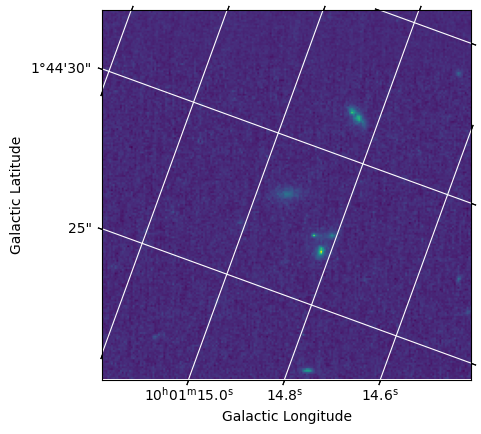

In [92]:
plt.subplot(projection=test_jwst.wcs)
plt.imshow(test_jwst.data, origin='lower')
plt.grid(color='white', ls='solid')
plt.xlabel('Galactic Longitude')
plt.ylabel('Galactic Latitude')

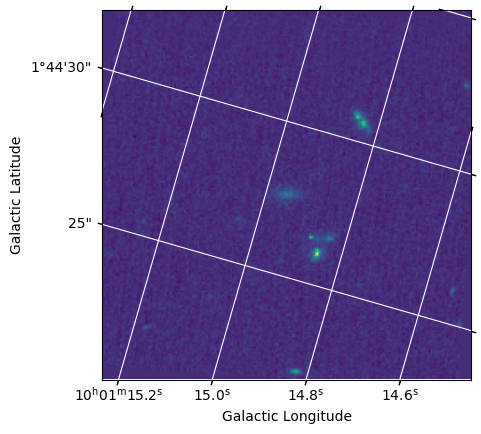

In [93]:
plt.subplot(projection=test_jwst_2.wcs)
plt.imshow(test_jwst_2.data, origin='lower')
plt.grid(color='white', ls='solid')
plt.xlabel('Galactic Longitude')
plt.ylabel('Galactic Latitude')

In [105]:
get_relative_rotation_vector(test_jwst, test_nisp_2)

3.946138983175969

/tmp/ipykernel_3510744/2511762995.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


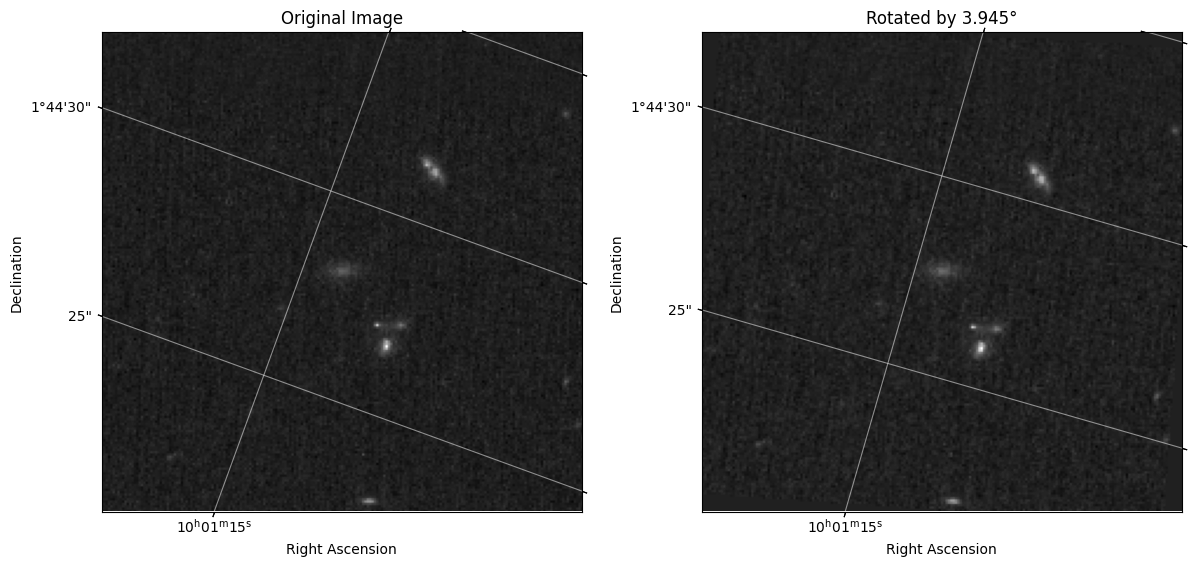

In [95]:
from astropy.visualization.wcsaxes import WCSAxes
def plot_with_wcs_grid(ax, data, wcs, title):
    """Plot data with WCS grid overlay"""
    ax.imshow(data, origin='lower', cmap='gray')
    ax.set_title(title)
    ax.grid(color='white', ls='solid', alpha=0.5)
    
    # Add coordinate labels
    ra = ax.coords[0]
    dec = ax.coords[1]
    ra.set_axislabel('Right Ascension')
    dec.set_axislabel('Declination')
    ra.set_major_formatter('hh:mm:ss')
    dec.set_major_formatter('dd:mm:ss')

# Create a figure with WCS-aware axes
fig = plt.figure(figsize=(12, 6))

# Original image
ax1 = WCSAxes(fig, [0.05, 0.1, 0.4, 0.8], wcs=test_jwst.wcs)
fig.add_axes(ax1)
plot_with_wcs_grid(ax1, test_jwst.data, test_jwst.wcs, 'Original Image')

# Rotated image
ax2 = WCSAxes(fig, [0.55, 0.1, 0.4, 0.8], wcs=test_jwst_2.wcs)
fig.add_axes(ax2)
plot_with_wcs_grid(ax2, test_jwst_2.data, test_jwst_2.wcs, f'Rotated by {3.945}°')

# Link the axes so they show the same region
ax1.coords.grid(color='white', alpha=0.5, linestyle='solid')
ax2.coords.grid(color='white', alpha=0.5, linestyle='solid')
ax1.set_xlim(0, test_jwst.data.shape[1]-1)
ax1.set_ylim(0, test_jwst.data.shape[0]-1)

plt.tight_layout()
plt.show()

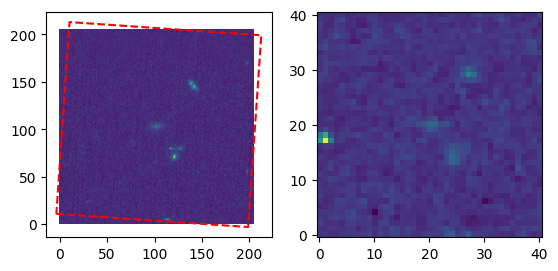

Base clip scale: 0.06 
Other clip scale: 0.30
Base clip should be 4.9456x larger than other clip


In [106]:
plot_on_clip(test_jwst, test_nisp_2)
# These are mirror-images of each other!

In [103]:
def test_rotation(cutout, angle_deg):
    """Test rotation by plotting original and rotated images with corner mapping"""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon
    
    # Rotate the cutout
    rotated_data, rotated_wcs = rotate_cutout_with_wcs(cutout, angle_deg)
    
    # Create a grid of points to visualize the transformation
    ny, nx = cutout.data.shape
    y, x = np.mgrid[0:ny:10, 0:nx:10]
    points = np.vstack([x.flatten(), y.flatten()]).T
    
    # Transform points from pixel to sky coordinates
    sky_coords = cutout.wcs.pixel_to_world(points[:,0], points[:,1])
    
    # Transform back to pixel coordinates in the rotated frame
    x_rot, y_rot = rotated_wcs.world_to_pixel(sky_coords)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original image
    ax1.imshow(cutout.data, origin='lower')
    ax1.plot(points[:,0], points[:,1], 'r+')
    ax1.set_title('Original Image')
    
    # Rotated image
    ax2.imshow(rotated_data, origin='lower')
    ax2.plot(x_rot, y_rot, 'r+')
    ax2.set_title(f'Rotated by {angle_deg}°')
    
    plt.tight_layout()
    plt.show()
    
    # Test corners specifically
    corners = np.array([[0, 0], [nx-1, 0], [nx-1, ny-1], [0, ny-1], [0, 0]])
    corners_sky = cutout.wcs.pixel_to_world(corners[:,0], corners[:,1])
    corners_rot = np.array(rotated_wcs.world_to_pixel(corners_sky)).T
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original image
    ax1.imshow(cutout.data, origin='lower')
    ax1.plot(corners[:,0], corners[:,1], 'r-', linewidth=2)
    ax1.set_title('Original Image')
    
    # Rotated image
    ax2.imshow(rotated_data, origin='lower')
    ax2.plot(corners_rot[:,0], corners_rot[:,1], 'r-', linewidth=2)
    ax2.set_title(f'Rotated by {angle_deg}°')
    
    plt.tight_layout()
    plt.show()
    
    return rotated_data, rotated_wcs

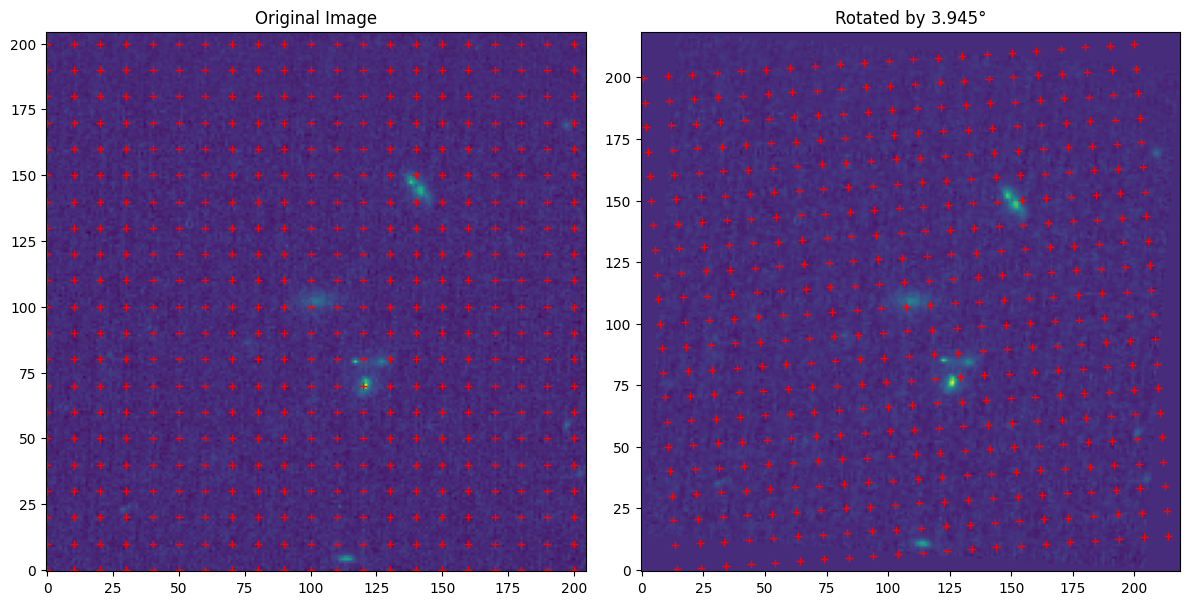

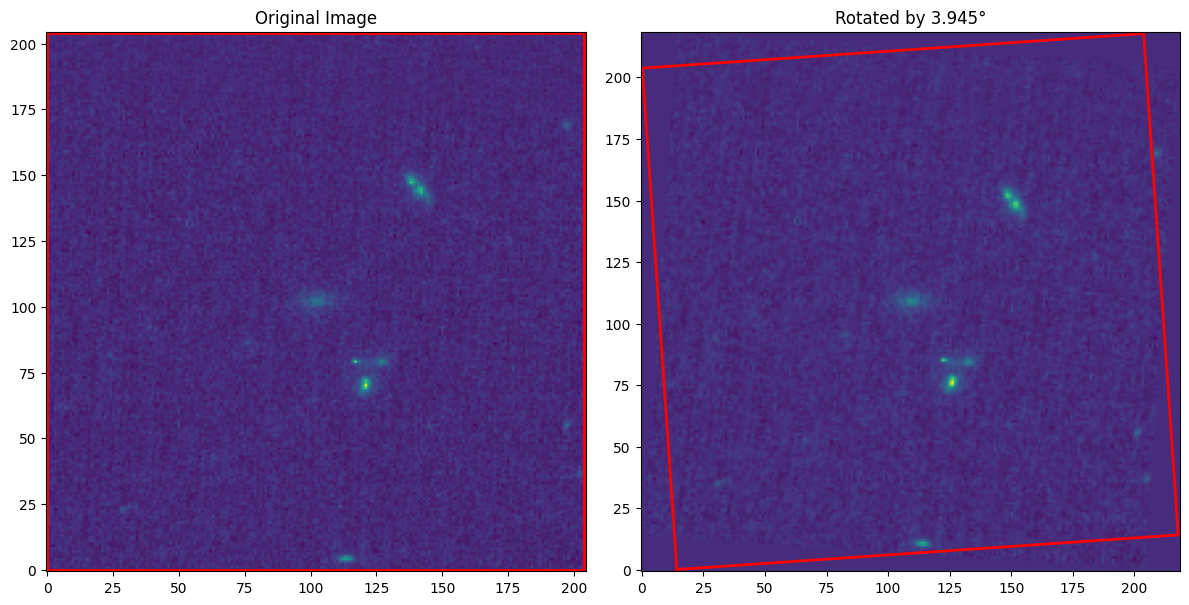

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN' 'DEC--TAN' 
 CRVAL : 150.1163213 2.200973097 
 CRPIX : 19031.338828463766 23373.387719514743 
 PC1_1 PC1_2  : -0.9609966602261617 0.2765599736660448 
 PC2_1 PC2_2  : 0.2765599736660448 0.9609966602261616 
 CDELT : 1.66666666666666e-05 1.66666666666666e-05 
 NAXIS : 205  205)

In [104]:
test_rotation(test_jwst, 3.945)

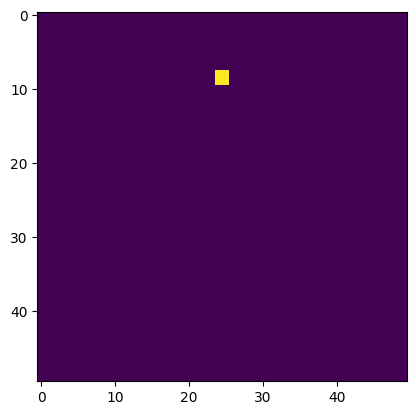

In [102]:
x = np.zeros([50, 50])
x[24:26, 40:42] = 1
y = ndimage.rotate(x, 90)
plt.imshow(y)

In [10]:
jwst_cutouts, nisp_cutouts = clips

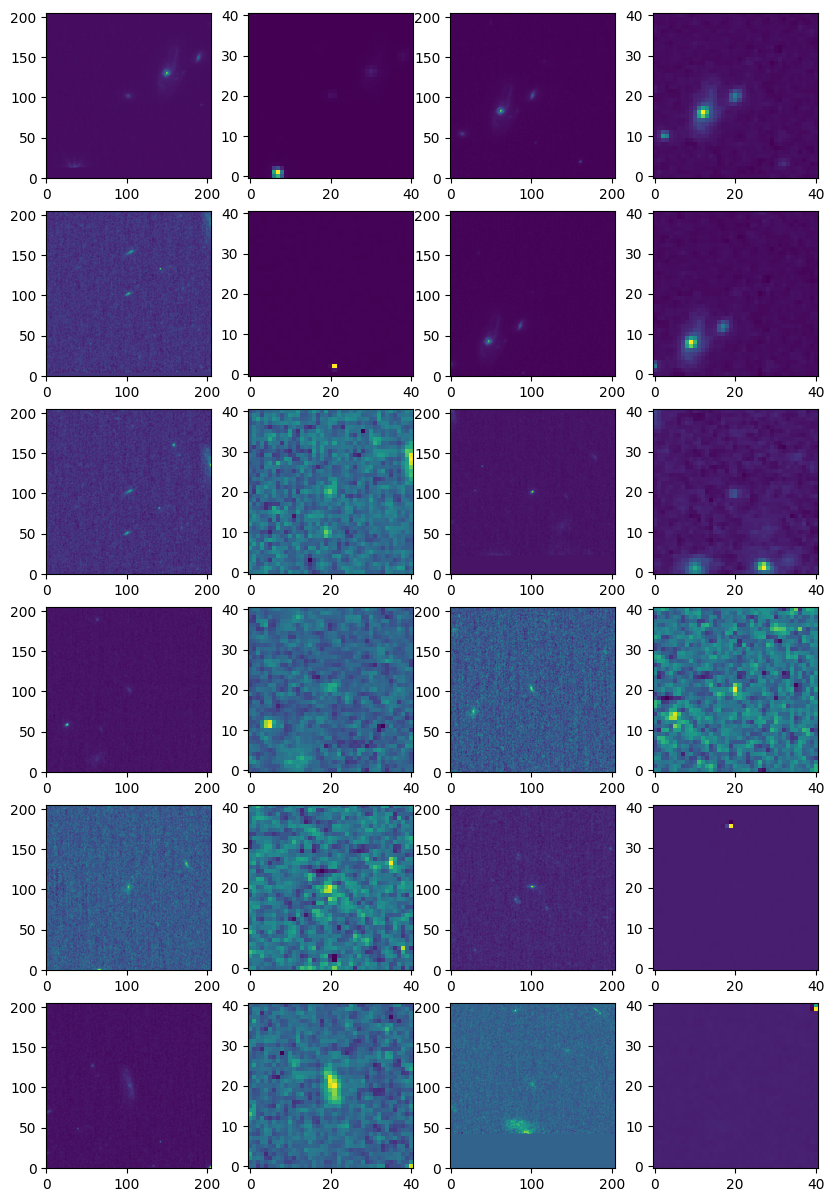

In [11]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst, origin='lower')
    axes.flatten()[i*2+1].imshow(clip_nisp, origin='lower')
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')

# Processing Euclid PSF file

In [9]:
import os
import sys
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import glob
import warnings
import numpy as np
import scipy
import pandas as pd
from importlib import reload
# 
from astropy.wcs import WCS
from astropy.nddata import NDData
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from astropy import units as u
from scipy import ndimage
from photutils.psf import GriddedPSFModel
from reproject import reproject_interp
from skimage import restoration

sys.path.insert(0, '/home/eaev/mer_psf/')
from mer.psf.MerCatalogPsf import MerCatalogPsf as mpsf

In [10]:
# # Instantiate dropbox token
# with open('../../secrets/dropbox_token') as token_file:
#     token = token_file.read()
#     dbx = dropbox.Dropbox(token.strip(), timeout=None)
# nisp_files = get_shared_folder_metadata(dbx_url, path='/new/', dbx=dbx)
# nisp_files = [file.name for file in nisp_files if 'IMAGE' in file.name]
# nisp_files

In [11]:
# nir_file = '../data/EUC_NIR_W-CAL-IMAGE_Y-3025-0_20241001T144757.480636Z.fits'
# with fits.open(nir_file) as hdul:
#     plt.imshow(hdul[7].data[1030:1070,1030:1070])

In [12]:
# clips = process_all('HUDF', redo_clips=True, save_clips=False)

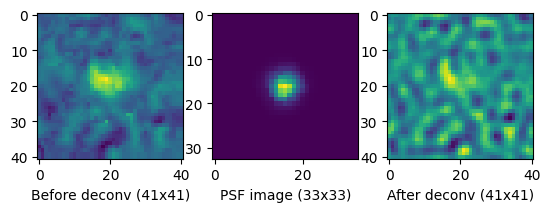

In [28]:
fig, axes = plt.subplots(1, 3)

idx = 200
test_nisp = np.pad(clips[idx][2].data, (0,1), mode='symmetric')
test_psf = clips[idx][3]

axes[0].imshow(test_nisp)
axes[0].set_xlabel("Before deconv (41x41)")
axes[1].imshow(test_psf)
axes[1].set_xlabel("PSF image (33x33)")

# Deconvolve
deconv, _ = restoration.unsupervised_wiener(test_nisp, test_psf, clip=False)
axes[2].imshow(deconv)
axes[2].set_xlabel("After deconv (41x41)")
plt.savefig("../plots/test_deconvolution.png", bbox_inches='tight')

In [13]:
# fname = '../data/NISP_PSF_HUDF_NIR_Y/euclid_hudf_nir_Y.sh'
# new_fname = fname.replace('nir_Y', 'nir_Y_psf_only')
# with open(fname, 'r') as file:
#     lines = file.readlines()
#     lines = [lines[0]]+[el for el in lines if ('PSF' in el)]
#     # lines = [lines[0]]+[el for el in lines if (('PSF' in el) and ('CATALOG' in el))]

# with open(new_fname, 'w') as file:
#     file.writelines(lines)

In [14]:
nir_psf_file = "../data/NISP_PSF_HUDF_NIR_Y/EUC_NIR_W-CAL-PSF-I_Y-3025-0_20241001T144843.454706Z.fits"

In [15]:
euclid_psf_file1 = "../data/NISP_PSF_HUDF_MER_Y/EUC_MER_CATALOG-PSF-NIR-Y_TILE102044185-B0A5EA_20241021T060047.722344Z_00.00.fits"
euclid_psf_file2 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE101541377-C9907F_20240805T181919.717517Z_00.00.fits"
euclid_psf_file3 = "../data/EUC_MER_GRID-PSF-NIR-Y_TILE102086074-9D515F_20250305T113121.621151Z_00.00.fits"

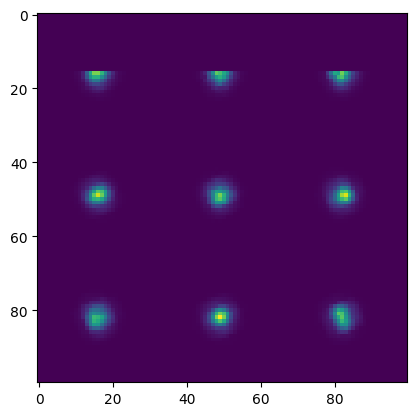

In [20]:
with fits.open(euclid_psf_file1) as hdul:
    hdr = hdul[1].header
    data = hdul[1].data
plt.imshow(data[:100,:100])

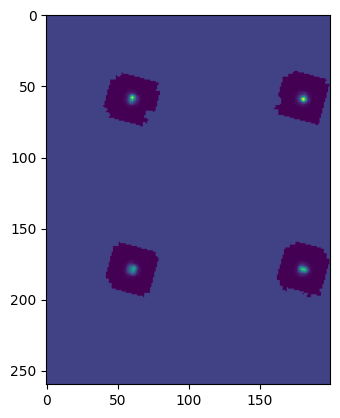

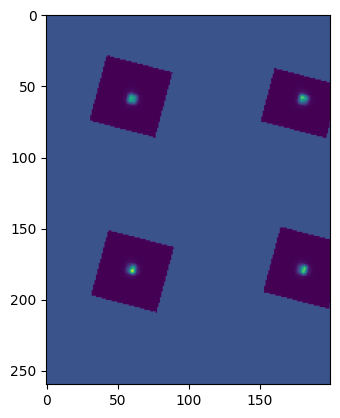

In [16]:
epsf2 = ep.EuclidPSF(euclid_psf_file2)
epsf3 = ep.EuclidPSF(euclid_psf_file3)

clip2 = epsf2.data[8581-60:8581+200,0:200].copy()
clip2[np.where(clip2==0)] = .01

clip3 = epsf3.data[5461-60:5461+200,0:200]
clip3[np.where(clip3==0)] = .01

plt.imshow(clip2)
plt.show()
plt.imshow(clip3)

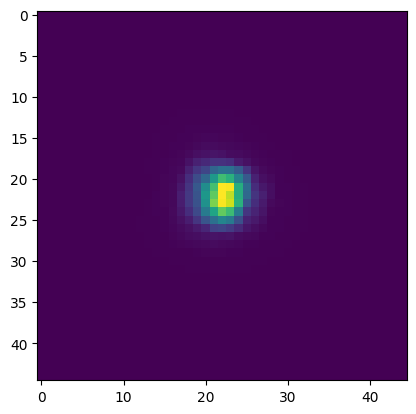

In [17]:
sc = epsf3.wcs.pixel_to_world(10000, 60000)
clip = epsf3.evaluate(sc)
plt.imshow(clip)

In [18]:
epsf3.psf_meta

,x,y,FWHM
0,61.0,5461.0,0.553758
1,61.0,5581.0,0.477654
2,61.0,5701.0,0.457173
3,61.0,5821.0,0.472023
4,61.0,5941.0,0.412781
...,...,...,...
14888,19141.0,18661.0,0.514245
14889,19141.0,18781.0,0.490489
14890,19141.0,18901.0,0.495918
14891,19141.0,19021.0,0.453218


In [19]:
epsf2.psf_meta

,x,y,FWHM
0,61.0,8581.0,0.449308
1,61.0,8701.0,0.539209
2,61.0,8821.0,0.510828
3,61.0,8941.0,0.474759
4,61.0,9061.0,0.517010
...,...,...,...
367,5581.0,10141.0,0.450341
368,5701.0,10141.0,0.468435
369,5821.0,10141.0,0.540504
370,5941.0,10141.0,0.463513


In [4]:
# psf1 = mpsf.from_file(euclid_psf_file1)

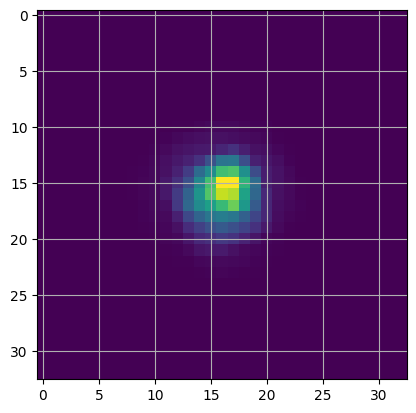

In [44]:
# psf_clip = psf1.get_closest_stamp_at_radec((52.978595, -27.723529))
# psf_clip.normalize()
# psf_data = psf_clip.get_data()
# plt.imshow(psf_data)
# plt.grid()

In [20]:
# with fits.open(euclid_psf_file1) as hdul:
#     hdr = hdul[1].header
#     hdr0 = hdul[0].header
#     wcs = WCS(hdr)
#     data = hdul[1].data
#     x_shape, y_shape = data.shape
# psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()

# print(wcs.pixel_to_world(17, 50))
# psf_info

# # psf_size = 120 # Size of PSF image
# # stamp_size = 33 # PSF stamp size in pixel units
# # oversamp = psf_size / stamp_size
# # n_psfs = int((x_shape / psf_size) * (y_shape / psf_size))
# # x_bounds = np.arange(0, x_shape, psf_size)
# # y_bounds = np.arange(0, y_shape, psf_size)

# # data_array = np.zeros((n_psfs, psf_size, psf_size), dtype=float)
# # grid_xypos = np.zeros((n_psfs, 2), dtype=int)

# psf_info['coord'] = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)

# # i = 0
# # for x in x_bounds:
# #     for y in y_bounds:
# #         data_array[i] = data[y:y+psf_size, x:x+psf_size]
# #         grid_xypos[i] = (x+psf_size/2,y+psf_size/2)
# #         i = i+1

# # meta = {
# #     'grid_xypos': grid_xypos,
# #     'oversampling': 4,
# # }
# # data_meta = NDData(data_array, meta=meta)
# # # After all that, the oversampling factor can't be a decimal
# # # It works if I just set the oversampling to 4, no thank you
# # # !@#@#@!@3 this
# # # Ok, the WCS is wrong on the PSF images, at least the catalog ones
# hdr

In [21]:
# psf_info

In [22]:
# zeros_high = data.copy()
# zeros_high[data==0] = .05
# center = np.array([50, 17])
# clip = Cutout2D(zeros_high, center-1, 33)
# plt.imshow(clip.data)
# plt.grid()

In [23]:
# plt.imshow(zeros_high[0:120, 0:120])

In [15]:
# import euclid_psf as ep

In [16]:
# reload(ep)

<module 'euclid_psf' from '/home/eaev/superNISP/code/euclid_psf.py'>

In [17]:
# epsf = ep.EuclidPSF(euclid_psf_file1)

In [28]:
# nisp_cutouts = np.load(meta['HUDF']['matched_nisp'])

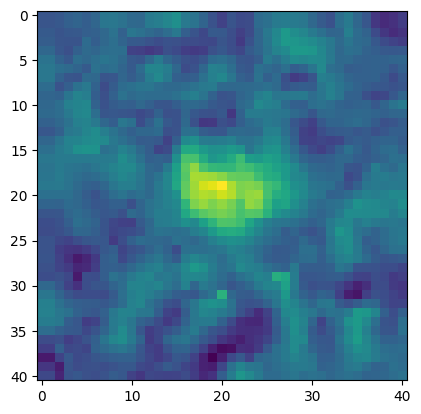

In [19]:
nisp_test = np.pad(clips[200][2].data, (1, 0), mode='symmetric')
plt.imshow(nisp_test)
psf_test = clips[200][3]

In [42]:
# psf_pt = epsf.evaluate(psf_info.coord[50])
# zoomed = scipy.ndimage.zoom(psf_pt, , order=3)
# # plt.imshow(zoomed)
# zoomed = np.pad(zoomed, 4, mode='symmetric')
# plt.imshow(zoomed)

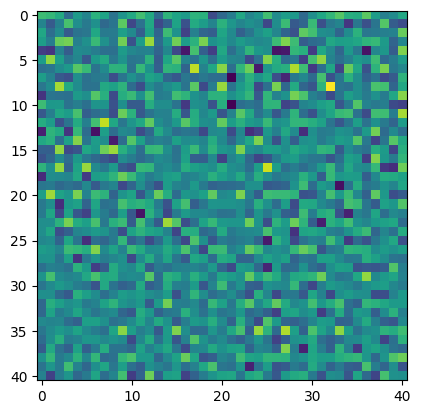

In [46]:
freq_img = np.fft.fft2(padded)
freq_img = np.fft.fftshift(freq_img)
freq_psf = np.fft.fft2(zoomed)
freq_psf = np.fft.fftshift(freq_psf)

maybe_deconv = np.fft.ifftshift(freq_img / freq_psf)
maybe_deconv = np.fft.ifftshift(np.fft.ifft2(maybe_deconv))
plt.imshow(maybe_deconv.real)

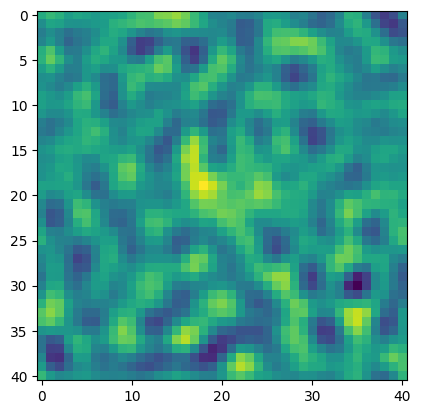

In [20]:
deconv, _ = restoration.unsupervised_wiener(nisp_test, psf_test, clip=False)
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.imshow(deconv)
# axes[1].imshow(padded)

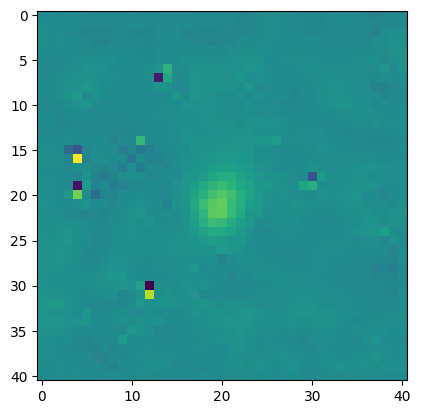

In [21]:
deconv = restoration.richardson_lucy(padded, zoomed, num_iter=30, clip=False)
plt.imshow(deconv)

In [12]:
coords = wcs.pixel_to_world(psf_info.y-1, psf_info.x-1)
psf_info.coord[0].separation(coords).degree

array([0.        , 0.00333323, 0.00666646, ..., 0.74482357, 0.74716929,
       0.7495225 ])

In [12]:
GriddedPSFModel(data_meta)

<GriddedPSFModel(flux=1., x_0=0., y_0=0.)>

In [28]:
with fits.open(euclid_psf_file2) as hdul:
    wcs = WCS(hdul[1].header)
    hdr = hdul[1].header

In [25]:
psf_info = Table.read(euclid_psf_file1, hdu=2).to_pandas()
xgrid = np.sort(np.unique(psf_info.x))

In [29]:
psf_info

,x,y,FWHM
0,61.0,61.0,0.457931
1,61.0,181.0,0.423055
2,61.0,301.0,0.490483
3,61.0,421.0,0.454768
4,61.0,541.0,0.487610
...,...,...,...
25525,19141.0,18661.0,0.445336
25526,19141.0,18781.0,0.439652
25527,19141.0,18901.0,0.481782
25528,19141.0,19021.0,0.425169
